# Graph ML — GCN Edge Classification & Label Propagation

**Goal:** Model the network as a graph and classify each traffic flow (edge) as BENIGN or ATTACK using:
1. **GCN Edge Classifier** — 2-layer GCN for node embeddings + MLP edge classifier
2. **Label Propagation** — parameter-free edge classification via IP reputation propagation
3. **Ensemble** — majority vote across XGBoost, GCN, and LP

**Input:** Prepared CSVs from `01_data_preparation.ipynb` (saved in `prepared_data/`).  
**Dataset:** Always uses the **TL (TrafficLabelling)** dataset since graph construction requires Source IP, Destination IP, and Timestamp columns.  
**Split:** Per-label chronological 70/15/15 (same as Per-Label Stratified Chronological Split in standard ML).  
**XGBoost baseline:** Loaded from saved results in `02_standard_ml.ipynb` (not retrained here).

## Configuration

In [1]:
from pydantic import BaseModel, Field


class GraphDataConfig(BaseModel):
    """Data loading and split settings."""
    prepared_data_dir: str = Field(default="prepared_data", description="Directory with prepared CSVs")
    use_correlation_features: bool = Field(default=False, description="Use correlation-selected feature subset")
    random_state: int = Field(default=42, description="Random seed")


class GCNConfig(BaseModel):
    """GCN Edge Classifier training settings."""
    hidden_dim: int = Field(default=128, description="GCN hidden dimension")
    dropout: float = Field(default=0.3)
    learning_rate: float = Field(default=1e-3)
    weight_decay: float = Field(default=1e-4)
    num_epochs: int = Field(default=100)
    edge_batch_size: int = Field(default=65536, description="Mini-batch size for edge classification")
    patience: int = Field(default=15, description="Early stopping patience")
    scheduler_factor: float = Field(default=0.5)
    scheduler_patience: int = Field(default=5)


class LPConfig(BaseModel):
    """Label Propagation settings."""
    max_iterations: int = Field(default=100)
    convergence_tol: float = Field(default=1e-8)
    threshold_search_step: float = Field(default=0.01, description="Step for threshold sweep")


class EnsembleConfig(BaseModel):
    """Ensemble settings."""
    run_ensemble: bool = Field(default=True)


data_cfg = GraphDataConfig()
gcn_cfg = GCNConfig()
lp_cfg = LPConfig()
ens_cfg = EnsembleConfig()

print("Configuration loaded:")
print(f"  Data: dir={data_cfg.prepared_data_dir}, corr_features={data_cfg.use_correlation_features}")
print(f"  GCN: hidden={gcn_cfg.hidden_dim}, epochs={gcn_cfg.num_epochs}, batch={gcn_cfg.edge_batch_size}, patience={gcn_cfg.patience}")
print(f"  LP: max_iter={lp_cfg.max_iterations}, tol={lp_cfg.convergence_tol}")

Configuration loaded:
  Data: dir=prepared_data, corr_features=False
  GCN: hidden=128, epochs=100, batch=65536, patience=15
  LP: max_iter=100, tol=1e-08


## Imports & Data Loading

In [2]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Base imports loaded.")

Base imports loaded.


In [4]:
import subprocess, sys

try:
    import torch
    print(f"PyTorch already installed: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
except ImportError:
    print("Installing PyTorch (CUDA 12.1)...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'torch', '--index-url', 'https://download.pytorch.org/whl/cu121'])
    import torch
    print(f"PyTorch installed: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

try:
    import torch_geometric
    print(f"PyG already installed: {torch_geometric.__version__}")
except ImportError:
    print("Installing PyG...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric'])
    import torch_geometric
    print(f"PyG installed: {torch_geometric.__version__}")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

gcn_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {gcn_device}")
if gcn_device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU: {props.name}")

# CUDA nvrtc fix (if needed)
try:
    import ctypes
    nvrtc_dir = "/usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvrtc/lib"
    if os.path.exists(nvrtc_dir):
        os.environ["LD_LIBRARY_PATH"] = nvrtc_dir + ":" + os.environ.get("LD_LIBRARY_PATH", "")
        ctypes.cdll.LoadLibrary(os.path.join(nvrtc_dir, "libnvrtc.so.12"))
        print("libnvrtc.so.12 loaded successfully.")
except Exception:
    pass

PyTorch already installed: 2.5.1+cu121, CUDA: True
PyG already installed: 2.7.0

Using device: cuda
  GPU: Quadro RTX 5000
libnvrtc.so.12 loaded successfully.


In [5]:
meta_path = os.path.join(data_cfg.prepared_data_dir, 'metadata.json')
with open(meta_path, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
label_mapping = metadata['label_mapping']

if data_cfg.use_correlation_features and 'selected_feature_cols' in metadata:
    active_feature_cols = metadata['selected_feature_cols']
    print(f"Using correlation-selected features")
else:
    active_feature_cols = feature_cols
    if data_cfg.use_correlation_features:
        print("WARNING: use_correlation_features=True but no selected features in metadata. Using all features.")
    print(f"Using all features")

tl_df = pd.read_csv(os.path.join(data_cfg.prepared_data_dir, 'tl_prepared.csv'), low_memory=False)
print(f"TL dataset loaded")

le = LabelEncoder()
le.classes_ = np.array(sorted(label_mapping.keys(), key=lambda x: label_mapping[x]))
class_names = le.classes_

Using ALL features: 63 features
TL dataset loaded: 2,827,677 rows x 71 cols
Label classes (15): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


## Per-Label Chronological Split

Reconstruct the same Per-Label Chronological Split used in standard ML for fair comparison.

In [6]:
# Parse timestamps and deduplicate
tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
tl_df['date'] = tl_df['Timestamp_parsed'].dt.date

ts_dedup_cols = active_feature_cols + ['Label']
ts_before = len(tl_df)
tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()

tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

# Per-label chronological 70/15/15 split
ls_train_parts, ls_val_parts, ls_test_parts = [], [], []

# print(f"\n{'Label':<30} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
# print("-" * 80)

for label in sorted(tl_df_dedup['Label'].unique()):
    label_df = tl_df_dedup[tl_df_dedup['Label'] == label]
    label_sorted = label_df.sort_values('Timestamp_parsed').reset_index(drop=True)
    n = len(label_sorted)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    ls_train_parts.append(label_sorted.iloc[:train_end])
    ls_val_parts.append(label_sorted.iloc[train_end:val_end])
    ls_test_parts.append(label_sorted.iloc[val_end:])

    # print(f"  {label:<28} {n:>8,} {train_end:>8,} {val_end - train_end:>8,} {n - val_end:>8,}")

ls_train_full = pd.concat(ls_train_parts, ignore_index=True)
ls_val_full = pd.concat(ls_val_parts, ignore_index=True)
ls_test_full = pd.concat(ls_test_parts, ignore_index=True)

print(f"\nTrain: {len(ls_train_full):,}, Val: {len(ls_val_full):,}, Test: {len(ls_test_full):,}")

# Verify all attack types present
for name, part in [('Train', ls_train_full), ('Val', ls_val_full), ('Test', ls_test_full)]:
    n_types = part[part['binary_label'] == 1]['Label'].nunique()
    # print(f"  {name} attack types: {n_types}")

Deduplication: 2,827,677 -> 2,520,961

Label                             Total    Train      Val     Test
--------------------------------------------------------------------------------
  BENIGN                       2,095,220 1,466,654  314,283  314,283
  Bot                             1,948    1,363      292      293
  DDoS                          128,014   89,609   19,202   19,203
  DoS GoldenEye                  10,286    7,200    1,543    1,543
  DoS Hulk                      172,846  120,992   25,927   25,927
  DoS Slowhttptest                5,228    3,659      784      785
  DoS slowloris                   5,385    3,769      808      808
  FTP-Patator                     5,931    4,151      890      890
  Heartbleed                         11        7        2        2
  Infiltration                       36       25        5        6
  PortScan                       90,694   63,485   13,604   13,605
  SSH-Patator                     3,219    2,253      483      483
  Web A

---
## GCN Edge Classification

### Architecture
```
Network Topology Graph (nodes = IPs, topology edges = unique IP pairs)
  → 2-layer GCN → Node Embeddings
  → Edge Classifier MLP: concat(h_src, h_dst, flow_features) → BENIGN/ATTACK
```

### Key Design Decisions
- **Transductive**: one graph, train/val/test edge masks from per-label chronological split
- **No leakage**: node features = mean of training edge features only; scaler fit on training edges only
- **Mini-batch training**: 64K edges per batch
- **Class-weighted BCE**: handles imbalance in unbalanced training set

In [8]:
# --- Graph construction from per-label chronological split ---

# Reconstruct full dataset in split order: train -> val -> test
gcn_df = pd.concat([ls_train_full, ls_val_full, ls_test_full], ignore_index=True)
n_train_g = len(ls_train_full)
n_val_g = len(ls_val_full)
n_test_g = len(ls_test_full)
print(f"Full dataset: {len(gcn_df):,} flows (train={n_train_g:,}, val={n_val_g:,}, test={n_test_g:,})")

# --- Map unique IPs to node indices ---
all_ips = pd.unique(gcn_df[['Source IP', 'Destination IP']].values.ravel())
ip_to_idx = {ip: i for i, ip in enumerate(all_ips)}
num_nodes = len(all_ips)
print(f"Unique IPs (nodes): {num_nodes}")

# --- Build full edge index (all flows) ---
src_idx = gcn_df['Source IP'].map(ip_to_idx).values.astype(np.int64)
dst_idx = gcn_df['Destination IP'].map(ip_to_idx).values.astype(np.int64)
full_edge_index = torch.tensor(np.stack([src_idx, dst_idx]), dtype=torch.long)

# --- Build topology edge index (unique IP pairs, undirected, for GCN message passing) ---
topo_pairs = np.unique(np.stack([src_idx, dst_idx], axis=1), axis=0)
topo_edge_index = torch.tensor(topo_pairs.T, dtype=torch.long)
topo_edge_index = to_undirected(topo_edge_index)
print(f"Topology edges (unique, undirected): {topo_edge_index.shape[1]}")

# --- Edge features: scale using training edges only ---
scaler_gcn = RobustScaler()
edge_feats_raw = gcn_df[active_feature_cols].values.astype(np.float32)
scaler_gcn.fit(edge_feats_raw[:n_train_g])
edge_feats_scaled = scaler_gcn.transform(edge_feats_raw).astype(np.float32)
edge_attr = torch.tensor(edge_feats_scaled, dtype=torch.float)

# --- Edge labels (binary) ---
edge_labels = torch.tensor(gcn_df['binary_label'].values.astype(np.float32), dtype=torch.float)

# --- Split masks ---
train_mask = torch.zeros(len(gcn_df), dtype=torch.bool)
train_mask[:n_train_g] = True
val_mask = torch.zeros(len(gcn_df), dtype=torch.bool)
val_mask[n_train_g:n_train_g + n_val_g] = True
test_mask = torch.zeros(len(gcn_df), dtype=torch.bool)
test_mask[n_train_g + n_val_g:] = True

# --- Node features: mean of incident training-edge features (no leakage) ---
node_feat_dim = len(active_feature_cols)
node_feat_accum = np.zeros((num_nodes, node_feat_dim), dtype=np.float64)
node_feat_count = np.zeros(num_nodes, dtype=np.float64)

train_edge_feats = edge_feats_scaled[:n_train_g]
train_src = src_idx[:n_train_g]
train_dst = dst_idx[:n_train_g]

np.add.at(node_feat_accum, train_src, train_edge_feats)
np.add.at(node_feat_count, train_src, 1)
np.add.at(node_feat_accum, train_dst, train_edge_feats)
np.add.at(node_feat_count, train_dst, 1)

has_train = node_feat_count > 0
node_feat_accum[has_train] /= node_feat_count[has_train, None]
x = torch.tensor(node_feat_accum.astype(np.float32), dtype=torch.float)

n_no_train = int((~has_train).sum())
print(f"Nodes with training edges: {int(has_train.sum())} / {num_nodes}")
if n_no_train > 0:
    print(f"  Nodes without training edges (zero features): {n_no_train}")

# --- Build PyG Data object ---
data = Data(x=x, edge_index=full_edge_index, edge_attr=edge_attr)
data.topo_edge_index = topo_edge_index
data.edge_labels = edge_labels
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"\nGraph summary:")
print(f"  Nodes:              {data.num_nodes:,}")
print(f"  Flow-edges (total): {data.num_edges:,}")
print(f"  Topology edges:     {topo_edge_index.shape[1]:,}")
print(f"  Node feature dim:   {data.x.shape[1]}")
print(f"  Edge feature dim:   {data.edge_attr.shape[1]}")
print(f"  Train edges: {train_mask.sum().item():,}  (ATTACK: {int((edge_labels[train_mask] == 1).sum()):,})")
print(f"  Val edges:   {val_mask.sum().item():,}  (ATTACK: {int((edge_labels[val_mask] == 1).sum()):,})")
print(f"  Test edges:  {test_mask.sum().item():,}  (ATTACK: {int((edge_labels[test_mask] == 1).sum()):,})")

# --- Move to GPU ---
data = data.to(gcn_device)
print(f"\nData moved to {gcn_device}")

Full dataset: 2,520,961 flows (train=1,764,666, val=378,144, test=378,151)
Unique IPs (nodes): 19065
Topology edges (unique, undirected): 123828
Nodes with training edges: 16525 / 19065
  Nodes without training edges (zero features): 2540

Graph summary:
  Nodes:              19,065
  Flow-edges (total): 2,520,961
  Topology edges:     123,828
  Node feature dim:   63
  Edge feature dim:   63
  Train edges: 1,764,666  (ATTACK: 298,012)
  Val edges:   378,144  (ATTACK: 63,861)
  Test edges:  378,151  (ATTACK: 63,868)

Data moved to cuda


In [9]:
# --- GCN Edge Classifier Model ---

class GCNEdgeClassifier(nn.Module):
    """
    2-layer GCN for node embeddings (on topology graph) +
    MLP edge classifier (on flow features + node embeddings).
    """
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        # GCN layers operate on the deduplicated topology graph
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout_rate = dropout

        # Edge classifier MLP: concat(h_src, h_dst, edge_features) -> output
        mlp_input_dim = hidden_dim * 2 + edge_feat_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def get_node_embeddings(self, x, topo_edge_index):
        """GCN message passing on the topology graph -> node embeddings."""
        h = F.relu(self.conv1(x, topo_edge_index))
        h = F.dropout(h, p=self.dropout_rate, training=self.training)
        h = self.conv2(h, topo_edge_index)
        return h

    def classify_edges_batch(self, h, edge_index, edge_attr, indices):
        """Classify a batch of edges given precomputed node embeddings."""
        src = edge_index[0, indices]
        dst = edge_index[1, indices]
        edge_repr = torch.cat([h[src], h[dst], edge_attr[indices]], dim=1)
        return self.edge_mlp(edge_repr).squeeze(-1)


gcn_model = GCNEdgeClassifier(
    node_feat_dim=data.x.shape[1],
    edge_feat_dim=data.edge_attr.shape[1],
    hidden_dim=gcn_cfg.hidden_dim,
    dropout=gcn_cfg.dropout,
).to(gcn_device)

total_params = sum(p.numel() for p in gcn_model.parameters())
print(f"Model: GCNEdgeClassifier")
print(f"  Total parameters: {total_params:,}")
print(f"\n{gcn_model}")


# --- Helper: evaluate edges in memory-safe chunks ---
@torch.no_grad()
def evaluate_edges(model, data, indices, chunk_size=65536):
    """Forward pass on edges in chunks -> concatenated logits."""
    model.eval()
    h = model.get_node_embeddings(data.x, data.topo_edge_index)
    all_logits = []
    for i in range(0, len(indices), chunk_size):
        chunk = indices[i:i + chunk_size]
        logits = model.classify_edges_batch(h, data.edge_index, data.edge_attr, chunk)
        all_logits.append(logits)
    return torch.cat(all_logits)

Model: GCNEdgeClassifier
  Total parameters: 73,985

GCNEdgeClassifier(
  (conv1): GCNConv(63, 128)
  (conv2): GCNConv(128, 128)
  (edge_mlp): Sequential(
    (0): Linear(in_features=319, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Class balance — BENIGN: 1,466,654, ATTACK: 298,012, pos_weight: 4.92
Training for up to 100 epochs (batch_size=65,536, patience=15)...

Epoch   1 | Train Loss: 37499.1681 | Val Loss: 2932.6843 | Val Acc: 0.9972 | Val F1: 0.9950 | LR: 1.00e-03
Epoch   5 | Train Loss: 119.2834 | Val Loss: 5.8058 | Val Acc: 0.8723 | Val F1: 0.8209 | LR: 1.00e-03
Epoch  10 | Train Loss: 31.6599 | Val Loss: 2.7754 | Val Acc: 0.8774 | Val F1: 0.8267 | LR: 5.00e-04
Epoch  15 | Train Loss: 17.4384 | Val Loss: 1.9790 | Val Acc: 0.8767 | Val F1: 0.8259 | LR: 2.50e-04

Early stopping at epoch 17. Best epoch: 2 (Val F1: 0.9980)

Training complete in 16.3s
Restored best model from epoch 2


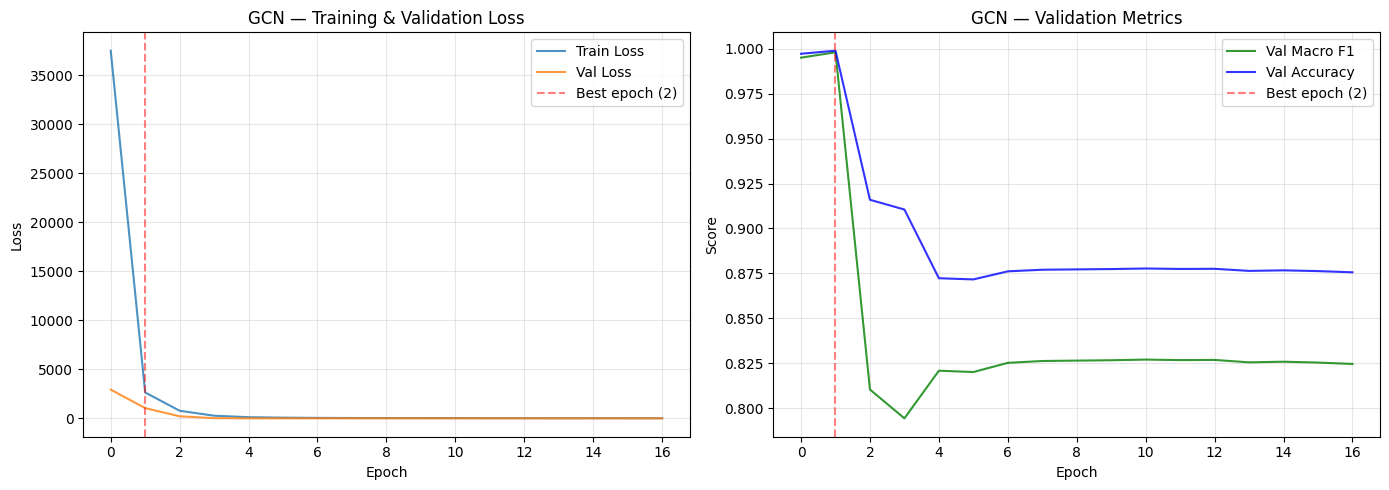

In [10]:
# --- Training loop: mini-batch edges with early stopping ---

# Precompute index tensors
train_idx = data.train_mask.nonzero(as_tuple=False).squeeze().to(gcn_device)
val_idx = data.val_mask.nonzero(as_tuple=False).squeeze().to(gcn_device)

# Class weight for imbalanced training set
n_pos_train = int((data.edge_labels[data.train_mask] == 1).sum())
n_neg_train = int((data.edge_labels[data.train_mask] == 0).sum())
pos_weight = torch.tensor([n_neg_train / n_pos_train], device=gcn_device)
print(f"Class balance — BENIGN: {n_neg_train:,}, ATTACK: {n_pos_train:,}, pos_weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=gcn_cfg.learning_rate, weight_decay=gcn_cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=gcn_cfg.scheduler_factor, patience=gcn_cfg.scheduler_patience
)

# Early stopping
best_val_f1 = 0.0
best_epoch = 0
patience_counter = 0
best_state = None

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}

print(f"Training for up to {gcn_cfg.num_epochs} epochs "
      f"(batch_size={gcn_cfg.edge_batch_size:,}, patience={gcn_cfg.patience})...\n")
t0_total = time.time()

for epoch in range(1, gcn_cfg.num_epochs + 1):
    # --- Train (mini-batch over edges) ---
    gcn_model.train()
    perm = torch.randperm(len(train_idx), device=gcn_device)
    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, len(perm), gcn_cfg.edge_batch_size):
        batch_perm = perm[i:i + gcn_cfg.edge_batch_size]
        batch_idx = train_idx[batch_perm]

        optimizer.zero_grad()
        h = gcn_model.get_node_embeddings(data.x, data.topo_edge_index)
        logits = gcn_model.classify_edges_batch(h, data.edge_index, data.edge_attr, batch_idx)
        loss = criterion(logits, data.edge_labels[batch_idx])
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_loss / n_batches

    # --- Validate (chunked, no grad) ---
    val_logits = evaluate_edges(gcn_model, data, val_idx)
    val_loss = criterion(val_logits, data.edge_labels[val_idx]).item()
    val_preds = (torch.sigmoid(val_logits) >= 0.5).cpu().numpy().astype(int)
    val_true = data.edge_labels[val_idx].cpu().numpy().astype(int)
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    scheduler.step(val_f1)

    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in gcn_model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | LR: {lr:.2e}")

    if patience_counter >= gcn_cfg.patience:
        print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch} (Val F1: {best_val_f1:.4f})")
        break

gcn_total_time = time.time() - t0_total
print(f"\nTraining complete in {gcn_total_time:.1f}s")

# Restore best model
gcn_model.load_state_dict(best_state)
gcn_model = gcn_model.to(gcn_device)
print(f"Restored best model from epoch {best_epoch}")

# --- Plot training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', alpha=0.8)
ax1.plot(history['val_loss'], label='Val Loss', alpha=0.8)
ax1.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('GCN — Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_f1'], label='Val Macro F1', color='green', alpha=0.8)
ax2.plot(history['val_acc'], label='Val Accuracy', color='blue', alpha=0.8)
ax2.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('GCN — Validation Metrics')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Classification Report — GCN Edge Classifier (TEST set)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    314283
      ATTACK       1.00      1.00      1.00     63868

    accuracy                           1.00    378151
   macro avg       1.00      1.00      1.00    378151
weighted avg       1.00      1.00      1.00    378151



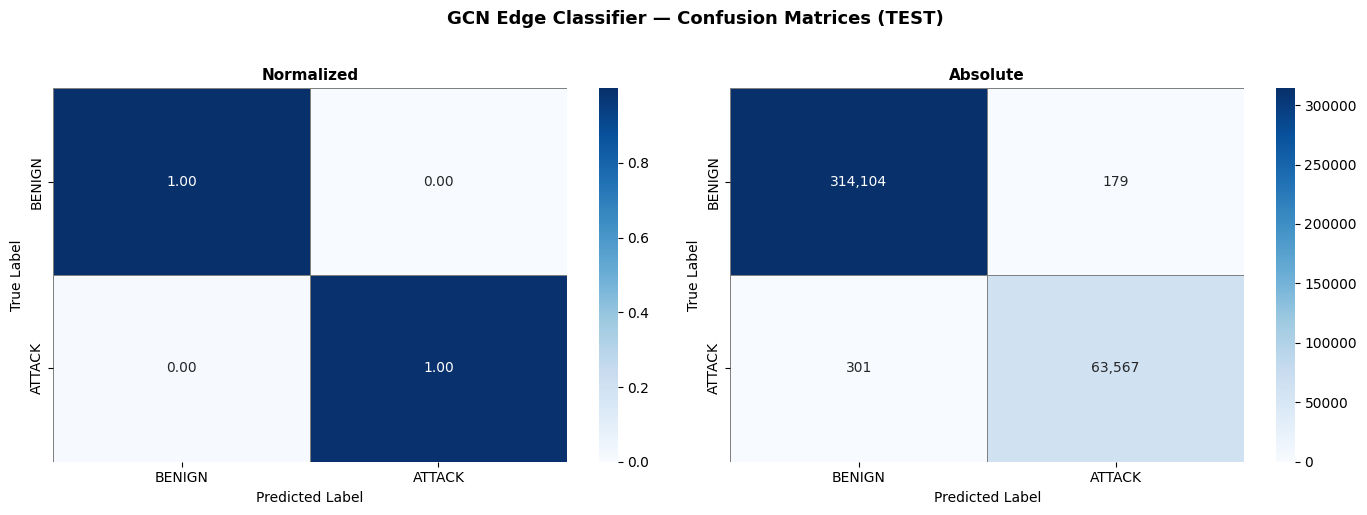


GCN vs XGBoost (S14 Baseline) — Test Set Comparison
                 Model Accuracy Macro F1 Weighted F1
XGBoost (S14 Baseline)   0.9970   0.9946      0.9970
   GCN Edge Classifier   0.9987   0.9977      0.9987


In [11]:
# --- Evaluate GCN on test set ---
test_idx = data.test_mask.nonzero(as_tuple=False).squeeze().to(gcn_device)

test_logits = evaluate_edges(gcn_model, data, test_idx)
test_probs = torch.sigmoid(test_logits).cpu().numpy()
gcn_test_preds = (test_probs >= 0.5).astype(int)
gcn_test_true = data.edge_labels[test_idx].cpu().numpy().astype(int)

gcn_class_names = np.array(['BENIGN', 'ATTACK'])

gcn_acc = accuracy_score(gcn_test_true, gcn_test_preds)
gcn_f1_macro = f1_score(gcn_test_true, gcn_test_preds, average='macro')
gcn_f1_weighted = f1_score(gcn_test_true, gcn_test_preds, average='weighted')

print("=" * 70)
print("Classification Report — GCN Edge Classifier (TEST set)")
print("=" * 70)
print(classification_report(gcn_test_true, gcn_test_preds, target_names=gcn_class_names))

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GCN Edge Classifier — Confusion Matrices (TEST)',
             fontsize=13, fontweight='bold', y=1.02)

cm = confusion_matrix(gcn_test_true, gcn_test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

for idx, (title, cm_data, fmt) in enumerate([
    ('Normalized', cm_norm, '.2f'),
    ('Absolute', cm, ',d'),
]):
    ax = axes[idx]
    sns.heatmap(cm_data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=gcn_class_names, yticklabels=gcn_class_names,
                ax=ax, vmin=0, linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
## Label Propagation for Edge Classification

**Algorithm:** Edge Label Propagation via Shared IP Nodes
1. Initialize: training edges = known labels, val/test edges = 0.5
2. Repeat: node scores = mean of incident edge scores; edge scores = mean of endpoint node scores; clamp training edges
3. Predict: score >= threshold -> ATTACK

**Properties:** 0 parameters, no features used, purely graph-structural.

In [13]:
# --- Edge Label Propagation via Shared IP Nodes ---

# Get data to CPU numpy for LP
lp_labels = data.edge_labels.cpu().numpy().astype(np.float64)
lp_train_mask = data.train_mask.cpu().numpy()
lp_val_mask = data.val_mask.cpu().numpy()
lp_test_mask = data.test_mask.cpu().numpy()

# Initialize edge scores: training = true labels, unlabeled = 0.5
lp_scores = np.full(len(lp_labels), 0.5, dtype=np.float64)
lp_scores[lp_train_mask] = lp_labels[lp_train_mask]

print("=" * 70)
print("Edge Label Propagation via Shared IP Nodes")
print("=" * 70)
print(f"\nEdges: {len(lp_labels):,}  (train={lp_train_mask.sum():,}, "
      f"val={lp_val_mask.sum():,}, test={lp_test_mask.sum():,})")
print(f"Nodes: {num_nodes:,}")
print(f"Max iterations: {lp_cfg.max_iterations},  convergence tol: {lp_cfg.convergence_tol}\n")

t0_lp = time.time()
lp_history_list = []

for lp_it in range(1, lp_cfg.max_iterations + 1):
    # Step 1: Aggregate edge scores -> node scores
    node_sum = np.zeros(num_nodes, dtype=np.float64)
    node_count = np.zeros(num_nodes, dtype=np.float64)
    np.add.at(node_sum, src_idx, lp_scores)
    np.add.at(node_count, src_idx, 1)
    np.add.at(node_sum, dst_idx, lp_scores)
    np.add.at(node_count, dst_idx, 1)
    lp_node_scores = np.where(node_count > 0, node_sum / node_count, 0.5)

    # Step 2: Update unlabeled edge scores from endpoint node means
    new_scores = 0.5 * (lp_node_scores[src_idx] + lp_node_scores[dst_idx])

    # Step 3: Clamp training edges to true labels
    new_scores[lp_train_mask] = lp_labels[lp_train_mask]

    # Convergence check (unlabeled edges only)
    unlabeled = ~lp_train_mask
    lp_delta = np.abs(lp_scores[unlabeled] - new_scores[unlabeled]).max()

    # Validation metrics at default threshold
    val_pred_iter = (new_scores[lp_val_mask] >= 0.5).astype(int)
    val_true_iter = lp_labels[lp_val_mask].astype(int)
    val_f1_iter = f1_score(val_true_iter, val_pred_iter, average='macro')
    val_acc_iter = accuracy_score(val_true_iter, val_pred_iter)

    lp_history_list.append({'iter': lp_it, 'delta': lp_delta,
                            'val_f1': val_f1_iter, 'val_acc': val_acc_iter})

    lp_scores = new_scores

    if lp_it <= 5 or lp_it % 10 == 0:
        print(f"  Iter {lp_it:3d} | delta_max = {lp_delta:.10f} | "
              f"Val Acc = {val_acc_iter:.4f} | Val F1 = {val_f1_iter:.4f}")

    if lp_delta < lp_cfg.convergence_tol:
        print(f"\n  Converged at iteration {lp_it} (delta = {lp_delta:.2e})")
        break

lp_time = time.time() - t0_lp
print(f"\nLabel Propagation completed in {lp_time:.2f}s ({lp_it} iterations)")

Edge Label Propagation via Shared IP Nodes

Edges: 2,520,961  (train=1,764,666, val=378,144, test=378,151)
Nodes: 19,065
Max iterations: 100,  convergence tol: 1e-08

  Iter   1 | delta_max = 0.4671200843 | Val Acc = 0.9934 | Val F1 = 0.9883
  Iter   2 | delta_max = 0.1646169298 | Val Acc = 0.9934 | Val F1 = 0.9883
  Iter   3 | delta_max = 0.0907916765 | Val Acc = 0.9932 | Val F1 = 0.9881
  Iter   4 | delta_max = 0.0534851039 | Val Acc = 0.9930 | Val F1 = 0.9877
  Iter   5 | delta_max = 0.0301416347 | Val Acc = 0.9931 | Val F1 = 0.9878
  Iter  10 | delta_max = 0.0013027362 | Val Acc = 0.9931 | Val F1 = 0.9878
  Iter  20 | delta_max = 0.0000019685 | Val Acc = 0.9931 | Val F1 = 0.9878

  Converged at iteration 29 (delta = 5.51e-09)

Label Propagation completed in 17.57s (29 iterations)


In [14]:
# --- Tune threshold on validation set ---
print(f"{'Threshold Tuning on Validation Set':=^70}")
val_scores_lp = lp_scores[lp_val_mask]
val_true_lp = lp_labels[lp_val_mask].astype(int)

lp_best_thr = 0.5
lp_best_val_f1 = 0.0
lp_thr_results = []

for thr in np.arange(0.01, 1.0, lp_cfg.threshold_search_step):
    preds = (val_scores_lp >= thr).astype(int)
    f1_m = f1_score(val_true_lp, preds, average='macro')
    lp_thr_results.append((thr, f1_m))
    if f1_m > lp_best_val_f1:
        lp_best_val_f1 = f1_m
        lp_best_thr = thr

print(f"  Best threshold: {lp_best_thr:.2f} (Val Macro F1: {lp_best_val_f1:.4f})")

print(f"\n  Threshold sweep (selected):")
for thr, f1_m in lp_thr_results:
    if abs(thr - lp_best_thr) < 0.001 or thr in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
        marker = " <-- best" if abs(thr - lp_best_thr) < 0.001 else ""
        print(f"    thr={thr:.2f}  Macro F1={f1_m:.4f}{marker}")

# --- Generate test predictions ---
lp_test_scores = lp_scores[lp_test_mask]
lp_test_preds = (lp_test_scores >= lp_best_thr).astype(int)
lp_test_true = lp_labels[lp_test_mask].astype(int)

==================Threshold Tuning on Validation Set==================
  Best threshold: 0.87 (Val Macro F1: 0.9891)

  Threshold sweep (selected):
    thr=0.20  Macro F1=0.9544
    thr=0.30  Macro F1=0.9544
    thr=0.40  Macro F1=0.9549
    thr=0.50  Macro F1=0.9878
    thr=0.60  Macro F1=0.9887
    thr=0.80  Macro F1=0.9890
    thr=0.87  Macro F1=0.9891 <-- best
    thr=0.90  Macro F1=0.9891


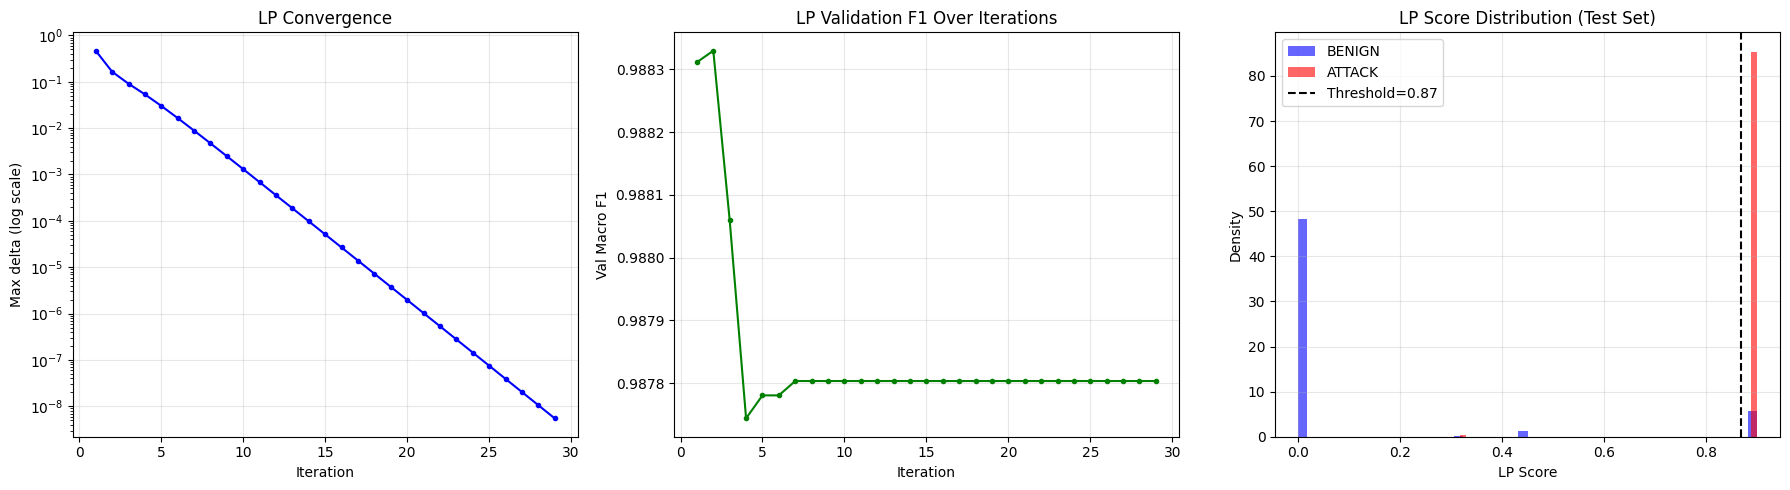


Test predictions ready: 378,151 flows, threshold=0.87


In [15]:
# --- LP Convergence & Score Distribution Plots ---
lp_hist_df = pd.DataFrame(lp_history_list)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convergence — delta
axes[0].semilogy(lp_hist_df['iter'], lp_hist_df['delta'], 'b-o', markersize=3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max delta (log scale)')
axes[0].set_title('LP Convergence')
axes[0].grid(True, alpha=0.3)

# Convergence — val F1
axes[1].plot(lp_hist_df['iter'], lp_hist_df['val_f1'], 'g-o', markersize=3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Val Macro F1')
axes[1].set_title('LP Validation F1 Over Iterations')
axes[1].grid(True, alpha=0.3)

# Score distribution for test set
test_benign_scores = lp_test_scores[lp_test_true == 0]
test_attack_scores = lp_test_scores[lp_test_true == 1]
axes[2].hist(test_benign_scores, bins=50, alpha=0.6, label='BENIGN', color='blue', density=True)
axes[2].hist(test_attack_scores, bins=50, alpha=0.6, label='ATTACK', color='red', density=True)
axes[2].axvline(lp_best_thr, color='black', linestyle='--', label=f'Threshold={lp_best_thr:.2f}')
axes[2].set_xlabel('LP Score')
axes[2].set_ylabel('Density')
axes[2].set_title('LP Score Distribution (Test Set)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTest predictions ready: {len(lp_test_preds):,} flows, threshold={lp_best_thr:.2f}")

Classification Report — Label Propagation (TEST set)
              precision    recall  f1-score   support

      BENIGN       1.00      0.90      0.95    314283
      ATTACK       0.66      1.00      0.80     63868

    accuracy                           0.91    378151
   macro avg       0.83      0.95      0.87    378151
weighted avg       0.94      0.91      0.92    378151



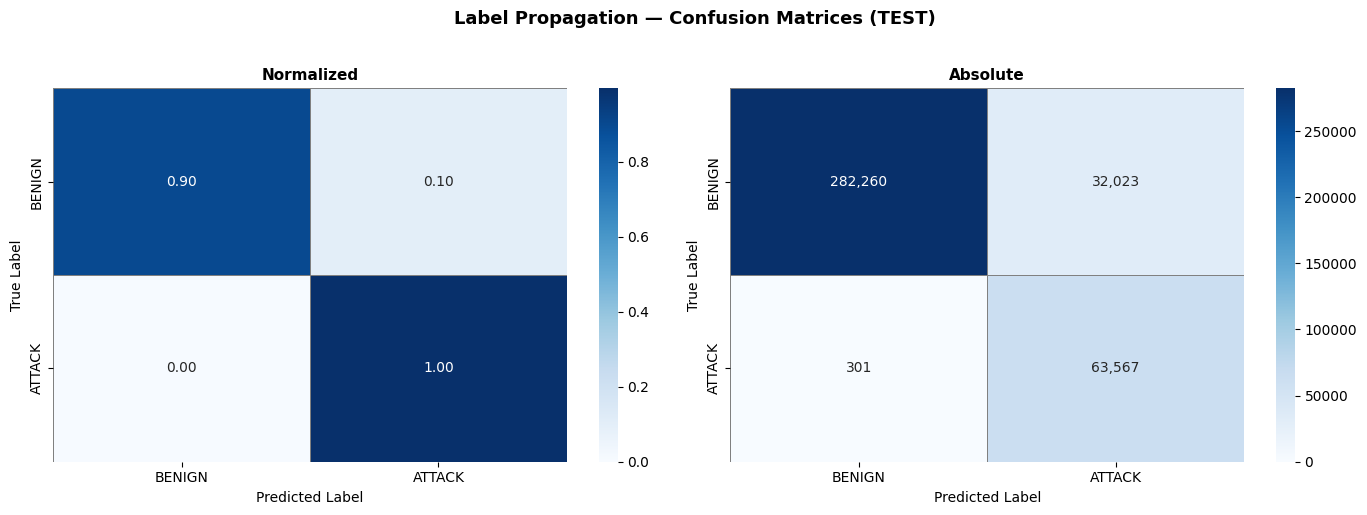

In [16]:
# --- LP Classification Report & Confusion Matrices ---

lp_acc = accuracy_score(lp_test_true, lp_test_preds)
lp_f1_macro = f1_score(lp_test_true, lp_test_preds, average='macro')
lp_f1_weighted = f1_score(lp_test_true, lp_test_preds, average='weighted')

lp_class_names = np.array(['BENIGN', 'ATTACK'])

print("=" * 70)
print("Classification Report — Label Propagation (TEST set)")
print("=" * 70)
print(classification_report(lp_test_true, lp_test_preds, target_names=lp_class_names))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label Propagation — Confusion Matrices (TEST)',
             fontsize=13, fontweight='bold', y=1.02)

cm_lp = confusion_matrix(lp_test_true, lp_test_preds)
cm_lp_norm = cm_lp.astype('float') / cm_lp.sum(axis=1, keepdims=True)

for idx, (title, cm_d, fmt) in enumerate([
    ('Normalized', cm_lp_norm, '.2f'),
    ('Absolute', cm_lp, ',d'),
]):
    ax = axes[idx]
    sns.heatmap(cm_d, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=lp_class_names, yticklabels=lp_class_names,
                ax=ax, vmin=0, linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
## Three-Way Comparison & Ensemble

In [17]:
# --- Load XGBoost baseline results from 02_standard_ml ---
xgb_results_path = os.path.join(data_cfg.prepared_data_dir, 'xgb_baseline_results.npz')
xgb_baseline = np.load(xgb_results_path)
xgb_test_preds = xgb_baseline['test_preds']
xgb_acc = float(xgb_baseline['accuracy'])
xgb_f1_macro = float(xgb_baseline['f1_macro'])
xgb_f1_weighted = float(xgb_baseline['f1_weighted'])
xgb_time = float(xgb_baseline['train_time'])
print(f"Loaded XGBoost baseline results from {xgb_results_path}")

# --- Three-Way Comparison Table ---
print("\n" + "=" * 70)
print("XGBoost vs GCN vs Label Propagation — Test Set Comparison")
print("=" * 70)

comparison_rows_3 = [
    {'Model': 'XGBoost (Per-Label Chrono)',
     'Accuracy': f"{xgb_acc:.4f}",
     'Macro F1': f"{xgb_f1_macro:.4f}",
     'Weighted F1': f"{xgb_f1_weighted:.4f}",
     'Train Time': f"{xgb_time:.1f}s"},
    {'Model': 'GCN Edge Classifier',
     'Accuracy': f"{gcn_acc:.4f}",
     'Macro F1': f"{gcn_f1_macro:.4f}",
     'Weighted F1': f"{gcn_f1_weighted:.4f}",
     'Train Time': f"{gcn_total_time:.1f}s"},
    {'Model': 'Label Propagation',
     'Accuracy': f"{lp_acc:.4f}",
     'Macro F1': f"{lp_f1_macro:.4f}",
     'Weighted F1': f"{lp_f1_weighted:.4f}",
     'Train Time': f"{lp_time:.1f}s"},
]

comparison_df_3 = pd.DataFrame(comparison_rows_3)
print(comparison_df_3.to_string(index=False))

XGBoost vs GCN vs Label Propagation — Test Set Comparison
                    Model Accuracy Macro F1 Weighted F1 Train Time
   XGBoost (S14 Baseline)   0.9970   0.9946      0.9970       2.0s
GCN Edge Classifier (S15)   0.9987   0.9977      0.9987      16.3s
  Label Propagation (S16)   0.9145   0.8716      0.9208      17.6s


In [18]:
# --- Three-Way Error Analysis: XGBoost vs GCN vs LP ---

if ens_cfg.run_ensemble:
    n_total_3 = len(lp_test_true)
    xgb_err = (xgb_test_preds != lp_test_true)
    gcn_err = (gcn_test_preds != lp_test_true)
    lp_err  = (lp_test_preds  != lp_test_true)

    print(f"{'Three-Way Error Analysis: XGBoost vs GCN vs LP':=^70}")
    print(f"\nTotal test flows: {n_total_3:,}")
    print(f"  XGBoost errors:  {xgb_err.sum():>6,}  ({xgb_err.sum()/n_total_3*100:.3f}%)")
    print(f"  GCN errors:      {gcn_err.sum():>6,}  ({gcn_err.sum()/n_total_3*100:.3f}%)")
    print(f"  LP errors:       {lp_err.sum():>6,}  ({lp_err.sum()/n_total_3*100:.3f}%)")

    # Venn-style breakdown
    all_correct   = int((~xgb_err & ~gcn_err & ~lp_err).sum())
    all_wrong     = int((xgb_err  &  gcn_err &  lp_err).sum())
    only_xgb_err3 = int((xgb_err  & ~gcn_err & ~lp_err).sum())
    only_gcn_err3 = int((~xgb_err &  gcn_err & ~lp_err).sum())
    only_lp_err3  = int((~xgb_err & ~gcn_err &  lp_err).sum())
    xgb_gcn_err   = int((xgb_err  &  gcn_err & ~lp_err).sum())
    xgb_lp_err    = int((xgb_err  & ~gcn_err &  lp_err).sum())
    gcn_lp_err    = int((~xgb_err &  gcn_err &  lp_err).sum())

    print(f"\n{'Agreement Breakdown':=^70}")
    print(f"  All 3 correct:         {all_correct:>8,}  ({all_correct/n_total_3*100:.2f}%)")
    print(f"  All 3 wrong:           {all_wrong:>8,}  ({all_wrong/n_total_3*100:.3f}%)")
    print(f"  Only XGBoost wrong:    {only_xgb_err3:>8,}  ({only_xgb_err3/n_total_3*100:.3f}%)")
    print(f"  Only GCN wrong:        {only_gcn_err3:>8,}  ({only_gcn_err3/n_total_3*100:.3f}%)")
    print(f"  Only LP wrong:         {only_lp_err3:>8,}  ({only_lp_err3/n_total_3*100:.3f}%)")
    print(f"  XGBoost + GCN wrong:   {xgb_gcn_err:>8,}  ({xgb_gcn_err/n_total_3*100:.3f}%)")
    print(f"  XGBoost + LP wrong:    {xgb_lp_err:>8,}  ({xgb_lp_err/n_total_3*100:.3f}%)")
    print(f"  GCN + LP wrong:        {gcn_lp_err:>8,}  ({gcn_lp_err/n_total_3*100:.3f}%)")

    # Rescue analysis
    print(f"\n{'Rescue Analysis':=^70}")
    for name_a, err_a, others in [
        ('XGBoost', xgb_err, [('GCN', gcn_err), ('LP', lp_err)]),
        ('GCN',     gcn_err, [('XGBoost', xgb_err), ('LP', lp_err)]),
        ('LP',      lp_err,  [('XGBoost', xgb_err), ('GCN', gcn_err)]),
    ]:
        if err_a.sum() == 0:
            continue
        print(f"  {name_a} ({err_a.sum():,} errors):")
        for name_b, err_b in others:
            rescues = int((err_a & ~err_b).sum())
            print(f"    {name_b} rescues: {rescues:,} ({rescues/err_a.sum()*100:.1f}%)")

    # --- Majority-vote ensemble (2 of 3) ---
    print(f"\n{'Ensemble: Majority Vote (2 of 3 say ATTACK)':=^70}")
    vote_sum = xgb_test_preds.astype(int) + gcn_test_preds.astype(int) + lp_test_preds.astype(int)
    majority_preds = (vote_sum >= 2).astype(int)
    maj_acc = accuracy_score(lp_test_true, majority_preds)
    maj_f1_macro = f1_score(lp_test_true, majority_preds, average='macro')
    maj_f1_weighted = f1_score(lp_test_true, majority_preds, average='weighted')

    print(f"  Accuracy:    {maj_acc:.4f}")
    print(f"  Macro F1:    {maj_f1_macro:.4f}")
    print(f"  Weighted F1: {maj_f1_weighted:.4f}")

    # Per-class error breakdown
    print(f"\n{'Error Breakdown by True Class':=^70}")
    for cls_v, cls_n in [(0, 'BENIGN'), (1, 'ATTACK')]:
        cls_m = (lp_test_true == cls_v)
        n_c = cls_m.sum()
        print(f"  {cls_n} ({n_c:,} flows):")
        for name, err in [('XGBoost', xgb_err), ('GCN', gcn_err), ('LP', lp_err),
                          ('Majority', majority_preds != lp_test_true)]:
            n_e = int((err & cls_m).sum())
            print(f"    {name:12s} errors: {n_e:>6,}  ({n_e/n_c*100:.2f}%)")
else:
    print("Ensemble analysis skipped.")

============Three-Way Error Analysis: XGBoost vs GCN vs LP============

Total test flows: 378,151
  XGBoost errors:   1,149  (0.304%)
  GCN errors:         480  (0.127%)
  LP errors:       32,324  (8.548%)

=========================Agreement Breakdown==========================
  All 3 correct:          345,255  (91.30%)
  All 3 wrong:                306  (0.081%)
  Only XGBoost wrong:         403  (0.107%)
  Only GCN wrong:             168  (0.044%)
  Only LP wrong:           31,574  (8.350%)
  XGBoost + GCN wrong:          1  (0.000%)
  XGBoost + LP wrong:         439  (0.116%)
  GCN + LP wrong:               5  (0.001%)

===========================Rescue Analysis============================
  XGBoost (1,149 errors):
    GCN rescues: 842 (73.3%)
    LP rescues: 404 (35.2%)
  GCN (480 errors):
    XGBoost rescues: 173 (36.0%)
    LP rescues: 169 (35.2%)
  LP (32,324 errors):
    XGBoost rescues: 31,579 (97.7%)
    GCN rescues: 32,013 (99.0%)

=============Ensemble: Majority Vote (2 of 